# Yields

### Data

Use the data file `../data/treasury_quotes_2025-04-30.xlsx`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
treasury_quotes = 'treasury_quotes_2025-04-30.xlsx'

# 1 YTM and Price

The problems in this section ask you to calculate the **yield-to-maturity (YTM)** of various bonds.

You will need to use a nonlinear solver to solve for the YTM.

For any given bond, YTM ($y$) solves...

$$p = \sum_{i=1}^{2n}\frac{Fc/2}{(1+y/2)^i} + \frac{F}{(1+y/2)^{2n}}$$

where
* $p$ is the bond's price.
* $n$ is the number of years to maturity
* $c$ is the coupon rate (a percentage)
* $F$ is the face value. Use $F=100$

#### Solving for YTM
Consider using `fsolve` to solve the yield implicitly from the nonlinear equation. This function is imported with...

`from scipy.optimize import fsolve`

### 1.1

Consider a semiannual bond with the following stylized parameters:
* time-to-maturity of 30 years
* coupon rate: 3%
* Face value of 100

1. Assume the YTM is 5%. Calculate the price.
1. Assume the price is 87. Calculate the YTM.

In [6]:
# 1.1 part 1
def price_from_ytm(y):
    n = 30
    c = 0.03
    F = 100
    coupon = F * c / 2
    periods = 2 * n
    rate_per_period = y / 2
    price = 0
    for i in range(1, periods + 1):
        price += coupon / (1 + rate_per_period)**i

    price += F / (1 + rate_per_period)**periods

    return price

print(price_from_ytm(0.05))

69.09134351494266


In [8]:
# 1.1 part 2
from scipy.optimize import fsolve

def ytm_equation(y):
    return price_from_ytm(y) - 87

result = fsolve(ytm_equation, 0.05)
print(result)
    

[0.03723107]


### 1.2

### Data
Use the data in the `selected quotes` tab.
* It gives treasury bond data for various maturities, spaced roughly six months apart.
* Feel free to approximate the time-to-maturity to be exactly semiannually if that is easier for the problem below.
* Use the `price` column for the price data in the YTM formula. (No need to worry about "dirty" price, bid, ask, nor accrued interest.)

1. Calculate the yield-to-maturity for each issue. How close are your calculations to the provided column `ytm`?

1. Plot the time-to-maturity (TTM) against the calculated YTM.

***

         ttm       ytm  calculated_ytm      ytm_diff
0   0.503765  0.041371        0.041686  3.147084e-04
1   0.999316  0.039086        0.039063 -2.312830e-05
2   1.503080  0.037147        0.037224  7.700918e-05
3   1.998631  0.035981        0.035959 -2.208241e-05
4   2.502396  0.035803        0.035838  3.465664e-05
5   3.000684  0.035912        0.035921  9.432437e-06
6   3.504449  0.036240        0.036285  4.520556e-05
7   4.000000  0.036603        0.036605  2.538668e-06
8   4.503765  0.036877        0.036908  3.073556e-05
9   4.999316  0.037173        0.037170 -2.415448e-06
10  5.503080  0.037870        0.037891  2.149067e-05
11  5.998631  0.038451        0.038446 -5.137258e-06
12  6.502396  0.038971        0.038986  1.493108e-05
13  7.000684  0.039286        0.039292  5.599849e-06
14  7.545517  0.039671        0.039686  1.534033e-05
15  8.041068  0.040339        0.040371  3.163814e-05
16  8.544832  0.040655        0.040656  5.430713e-07
17  9.040383  0.041169        0.041160 -9.3710

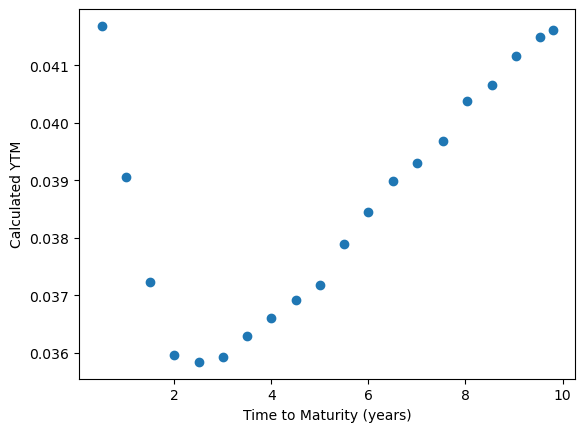

In [27]:
# 1.2
selected_quotes = pd.read_excel(treasury_quotes, sheet_name='selected quotes')

def price_from_ytm(y, n, c, F=100):
    coupon = F * c / 2
    periods = round(2 * n)
    rate_per_period = y / 2

    price = 0
    for i in range(1, periods + 1):
        price += coupon / (1 + rate_per_period)**i

    price += F / (1+rate_per_period)**periods

    return price

def ytm_equation(y, n, c, F, target_price):
    return price_from_ytm(y, n, c, F) - target_price

calculated_ytm = []
for idx, row in selected_quotes.iterrows():
    n = row['ttm']
    c = row['cpn rate'] / 100
    result = fsolve(ytm_equation, 0.04, args=(n, c, 100, row['price']))
    calculated_ytm.append(result[0])

selected_quotes['calculated_ytm'] = calculated_ytm
selected_quotes['ytm_diff'] = selected_quotes['calculated_ytm'] - selected_quotes['ytm']
print(selected_quotes[['ttm', 'ytm', 'calculated_ytm', 'ytm_diff']])

# We see that there are very very small differences between the ytm and the calculated ytm which is good.
plt.scatter(selected_quotes['ttm'], selected_quotes['calculated_ytm'])
plt.xlabel('Time to Maturity (years)')
plt.ylabel('Calculated YTM')
plt.show()

# 2 Yields Across Maturities

### Data
Use the data in the `selected quotes` tab.

Focus on the nominal securities. 
* Exclude any row with `type` of `TIPS note` or `TIPS bond`.

### 2.1
Plot the time-to-maturity against the provided YTM.

### 2.2

1. Calculate the YTM of each (nominal) bond issue in the data set. 

1. Report how far your YTM calculation is from those reported in the data set.

1. Report your calculated YTM for the issues where the dataset does not provide a YTM.


### 2.3

For the Treasury bills, calculate the **discount yields**.

Identify the T-bills using `type`=`bill` or looking for `cpnrate` of 0.

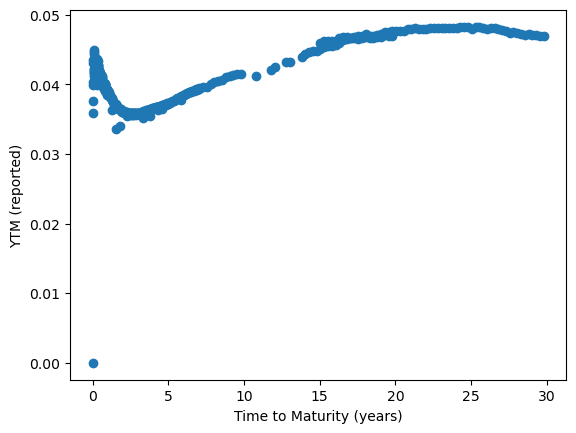

In [29]:
# 2.1, used quotes instead of selected quotes tab because selected quotes does not have bills/bonds/TIPS
quotes = pd.read_excel('treasury_quotes_2025-04-30.xlsx', sheet_name='quotes')
nominal_quotes = quotes[~quotes['type'].isin(['TIPS note', 'TIPS bond'])].copy()

plt.scatter(nominal_quotes['ttm'], nominal_quotes['ytm'])
plt.xlabel('Time to Maturity (years)')
plt.ylabel('YTM (reported)')
plt.show()

In [35]:
# 2.2
calculated_ytm = []
for idx, row in nominal_quotes.iterrows():
    n = row['ttm']
    c = row['cpn rate'] / 100
    result = fsolve(ytm_equation, 0.04, args=(n, c, 100, row['price']))
    calculated_ytm.append(result[0])
    
nominal_quotes['calculated_ytm']= calculated_ytm
nominal_quotes['ytm_diff']=nominal_quotes['calculated_ytm'] - nominal_quotes['ytm']
print(nominal_quotes['ytm_diff'].describe())

count    396.000000
mean      -0.000767
std        0.004357
min       -0.021277
25%       -0.000806
50%       -0.000016
75%        0.000082
max        0.040000
Name: ytm_diff, dtype: float64


/var/folders/d3/9bvhzsg16gv82z5vyh1hcswm0000gn/T/ipykernel_86360/4233876201.py:6: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  result = fsolve(ytm_equation, 0.04, args=(n, c, 100, row['price']))


In [37]:
# 2.3
bills = nominal_quotes[nominal_quotes['type'] == 'bill'].copy()
bills['days_to_maturity'] = (bills['maturity date'] - bills['quote date']).dt.days
F = 100
bills['discount_yield'] = (F - bills['price']) / F * (360 / bills['days_to_maturity'])
print(bills[['maturity date', 'days_to_maturity', 'price', 'discount_yield', 'ytm']].head(10))

   maturity date  days_to_maturity       price  discount_yield       ytm
0     2025-05-01                 1  100.000000        0.000000  0.000000
1     2025-05-06                 6   99.941681        0.034992  0.035829
2     2025-05-08                 8   99.918333        0.036750  0.037651
3     2025-05-13                13   99.859667        0.038862  0.039848
5     2025-05-15                15   99.836278        0.039293  0.040300
7     2025-05-20                20   99.776750        0.040185  0.041236
8     2025-05-22                22   99.752795        0.040452  0.041518
9     2025-05-27                27   99.695092        0.040654  0.041740
10    2025-05-29                29   99.672182        0.040695  0.041786
14    2025-06-03                34   99.614007        0.040870  0.041981


In [ ]:
# We see that discount yields for T-bills are consistently a bit lower than their expected YTM.
# This reflects the discount-yield convention's use of face value as the denominator and a 360-day year.
# Unlike the semiannual YTM formula, the discount yield calculation handles very short maturity bills correctly,
# since it doesn't rely on counting whole coupon periods.